<a href="https://colab.research.google.com/github/Amulya-Rao-mj/ML2_lab--Amulya-Rao-M-J--4NI23CI013/blob/main/MLlab2_Naive_Bayes_Theorem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

df = pd.read_csv('Mall_Customers.csv')

print(df.head())
print(df.info())
print("Missing values:\n", df.isnull().sum())


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
Missing values:
 CustomerID                0
Genre 

In [2]:

df.fillna(df.mean(numeric_only=True), inplace=True)

df['Target_Group'] = pd.qcut(df['Spending Score (1-100)'], q=3, labels=['Low', 'Medium', 'High'])

x = df[['Age', 'Annual Income (k$)']].copy()
y = df['Target_Group']



In [3]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)



In [4]:
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))



Training samples: 160
Testing samples: 40


In [5]:
model = GaussianNB()
model.fit(x_train, y_train)



GaussianNB()

In [6]:
y_pred = model.predict(x_test)
print("Actual:", y_test[:10])
print("Predicted:", y_pred[:10])



Actual: [0 1 0 1 2 2 2 2 2 2]
Predicted: [0 0 0 0 0 2 2 2 2 2]


In [7]:
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)



precision: 0.7190
recall: 0.7000
f1: 0.6873
accuracy: 0.7000


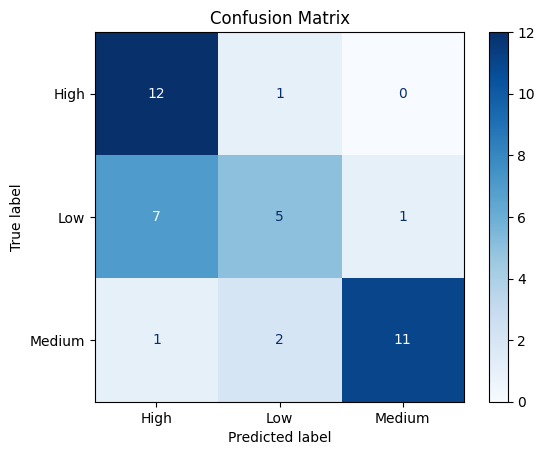

In [8]:
print(f"precision: {precision:.4f}")
print(f"recall: {recall:.4f}")
print(f"f1: {f1:.4f}")
print(f"accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()